# 03 — Modelos Baseline
## DengAI: Predicting Disease Spread

Neste notebook construímos os primeiros modelos preditivos sobre os dados processados.


Usamos dois modelos de baseline:
- **Negative Binomial Regression** (statsmodels) — modelo estatístico adequado para count data
- **Random Forest Regressor** (scikit-learn) — baseline de ML robusto e interpretável




### Importações e carregamento dos dados processados


In [1]:
import pandas as pd                          # DataFrames (pandas-dev/pandas)
import numpy as np                           # operações numéricas (numpy/numpy)
import matplotlib.pyplot as plt              # gráficos (matplotlib/matplotlib)
import seaborn as sns                        # gráficos estatísticos (mwaskom/seaborn)
import warnings                              # suprimir avisos (stdlib)
import time                                  # medir tempo de treino (stdlib)

from sklearn.ensemble import RandomForestRegressor  # Random Forest (scikit-learn)
from sklearn.model_selection import TimeSeriesSplit # CV para séries temporais (scikit-learn)
from sklearn.metrics import mean_absolute_error     # métrica MAE (scikit-learn)
from sklearn.preprocessing import StandardScaler   # normalização (scikit-learn)
import statsmodels.api as sm                        # NB regression (statsmodels)
import statsmodels.formula.api as smf              # fórmulas R-style (statsmodels)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

# Carregar dados processados
train_sj = pd.read_csv('database/processed/train_sj.csv')
train_iq = pd.read_csv('database/processed/train_iq.csv')
test_sj  = pd.read_csv('database/processed/test_sj.csv')
test_iq  = pd.read_csv('database/processed/test_iq.csv')

print(f"Treino SJ carregado: {train_sj.shape}")
print(f"Treino IQ carregado: {train_iq.shape}")
print(f"Teste  SJ carregado: {test_sj.shape}")
print(f"Teste  IQ carregado: {test_iq.shape}")


Treino SJ carregado: (932, 86)
Treino IQ carregado: (516, 86)
Teste  SJ carregado: (260, 84)
Teste  IQ carregado: (156, 84)


### 1. Definição das Features e do Target

Seleccionamos as colunas que serão usadas como input (X) e como output (y).
Excluímos os identificadores (`city`, `year`, `weekofyear`, `week_start_date`)
e o target original não transformado.

Usamos `total_cases_log` = log(total_cases + 1) como target para os modelos de ML
(Random Forest), mas o target original `total_cases` para o modelo Negative Binomial
(que tem a sua própria função de link logarítmica interna).


In [2]:
# Colunas a excluir (identificadores e targets duplicados)
excluir = ['city', 'year', 'weekofyear', 'week_start_date',
           'total_cases', 'total_cases_log']

# Features para modelos de ML
feat_cols = [c for c in train_sj.columns if c not in excluir]

print(f"Número total de features para modelação: {len(feat_cols)}")
print("\nGrupos de features:")
print(f"  Originais:     {len([c for c in feat_cols if '_lag' not in c and '_roll' not in c and c not in ['week_sin','week_cos']])}")
print(f"  Lag features:  {len([c for c in feat_cols if '_lag' in c])}")
print(f"  Rolling avgs:  {len([c for c in feat_cols if '_roll' in c])}")
print(f"  Encoding cíc.: {len([c for c in feat_cols if c in ['week_sin','week_cos']])}")

# Preparar X e y para cada cidade
X_sj = train_sj[feat_cols].values
y_sj = train_sj['total_cases_log'].values    # target transformado para RF
y_sj_orig = train_sj['total_cases'].values   # target original para NB e avaliação

X_iq = train_iq[feat_cols].values
y_iq = train_iq['total_cases_log'].values
y_iq_orig = train_iq['total_cases'].values

print(f"\nShape X_sj: {X_sj.shape}  |  y_sj: {y_sj.shape}")
print(f"Shape X_iq: {X_iq.shape}  |  y_iq: {y_iq.shape}")


Número total de features para modelação: 80

Grupos de features:
  Originais:     20
  Lag features:  40
  Rolling avgs:  18
  Encoding cíc.: 2

Shape X_sj: (932, 80)  |  y_sj: (932,)
Shape X_iq: (516, 80)  |  y_iq: (516,)


### 2. Validação Cruzada com TimeSeriesSplit

**Porquê TimeSeriesSplit e não KFold ou train_test_split aleatório?**

Em séries temporais, o futuro não pode ser usado para prever o passado.
O `KFold` standard embaralha os dados , um fold de teste poderia conter semanas
de 2002, enquanto o treino incluiria semanas de 2005. Isto é *data leakage* temporal
e resulta em métricas artificialmente optimistas que não reflectem a performance real.

O `TimeSeriesSplit` garante que o conjunto de teste de cada fold está sempre
**temporalmente depois** do conjunto de treino, respeitando a estrutura causal dos dados.

> `sklearn.model_selection.TimeSeriesSplit` —  
> [sklearn docs](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)  



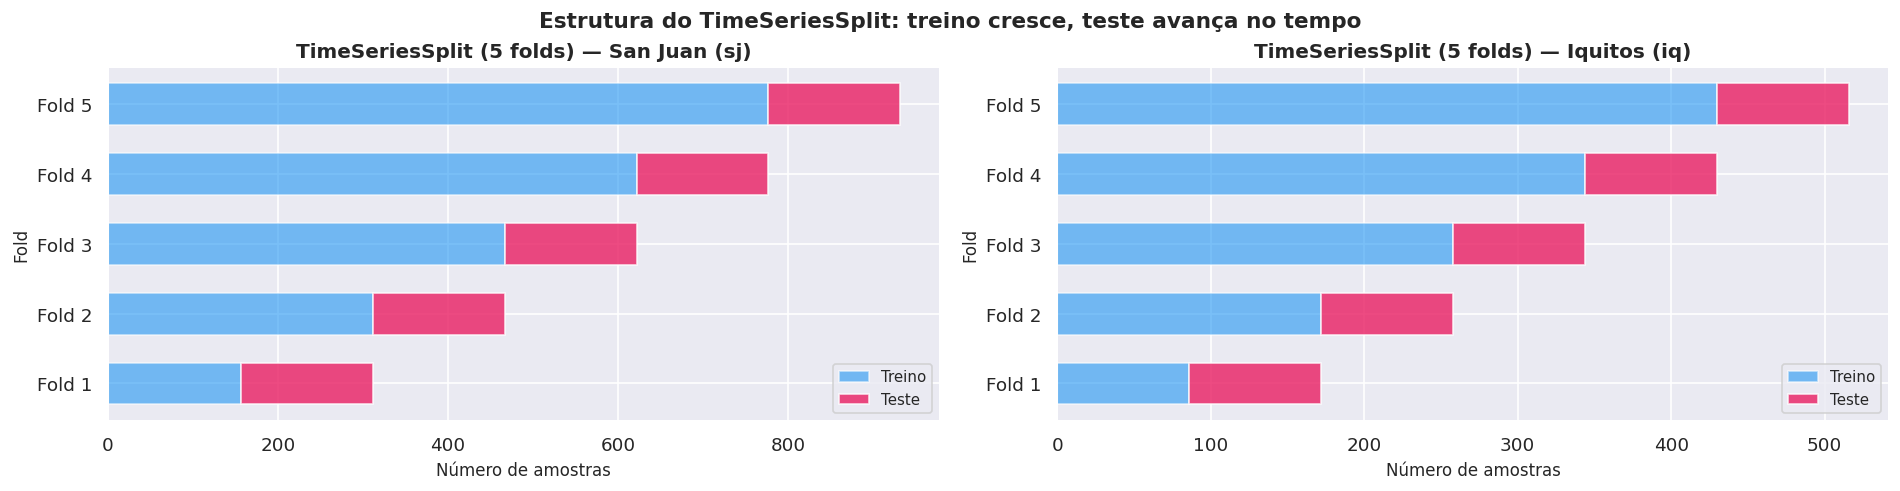


TimeSeriesSplit configurado com 5 folds.
Cada fold: treino até semana T, teste nas semanas T+1 a T+N.


In [3]:
N_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

# Visualizar os folds para ter intuição do split
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, X, nome in zip(axes, [X_sj, X_iq], ['San Juan (sj)', 'Iquitos (iq)']):
    n = len(X)
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        ax.barh(fold, len(train_idx), color='#2196F3', alpha=0.6, height=0.6,
                label='Treino' if fold == 0 else '')
        ax.barh(fold, len(test_idx), left=len(train_idx),
                color='#E91E63', alpha=0.8, height=0.6,
                label='Teste' if fold == 0 else '')
    ax.set_title(f'TimeSeriesSplit ({N_FOLDS} folds) — {nome}', fontweight='bold')
    ax.set_xlabel('Número de amostras')
    ax.set_ylabel('Fold')
    ax.legend(fontsize=9)
    ax.set_yticks(range(N_FOLDS))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])

plt.tight_layout()
plt.suptitle('Estrutura do TimeSeriesSplit: treino cresce, teste avança no tempo',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f"\nTimeSeriesSplit configurado com {N_FOLDS} folds.")
print("Cada fold: treino até semana T, teste nas semanas T+1 a T+N.")


### 3. Modelo 1 — Negative Binomial Regression

**Porquê Negative Binomial e não Poisson?**

`total_cases` é count data, inteiros não-negativos. A regressão de Poisson seria
a escolha natural, mas assume que a variância é **igual** à média (equidispersão).
Os nossos dados têm **sobredispersão**, a variância é muito maior do que a média
(em sj: média ~34, variância ~2300), o que viola a premissa do Poisson.

A **Negative Binomial** adiciona um parâmetro de dispersão que permite modelar
esta variância extra, sendo mais adequada para dados de saúde pública com surtos esporádicos.

Usamos apenas as features climáticas originais mais relevantes (sem lags) para o modelo
estatístico, porque o NB converge melhor com menos variáveis.





In [4]:
# Features reduzidas para NB (modelo estatístico tem dificuldade com 70+ features)
nb_features = [
    'reanalysis_specific_humidity_g_per_kg',
    'reanalysis_dew_point_temp_k',
    'reanalysis_avg_temp_k',
    'reanalysis_relative_humidity_percent',
    'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw',
    'precipitation_amt_mm',
    'week_sin', 'week_cos',
]

def treinar_nb_cv(train_df, y_orig, cidade):
    """Treina Negative Binomial com TimeSeriesSplit e devolve MAE por fold."""
    X_nb = train_df[nb_features].values
    mae_folds = []
    tscv_nb = TimeSeriesSplit(n_splits=N_FOLDS)

    for fold, (tr_idx, te_idx) in enumerate(tscv_nb.split(X_nb)):
        X_tr, X_te = X_nb[tr_idx], X_nb[te_idx]
        y_tr, y_te = y_orig[tr_idx], y_orig[te_idx]

        # Adicionar constante (intercepto)
        X_tr_c = sm.add_constant(X_tr, has_constant='add')
        X_te_c = sm.add_constant(X_te, has_constant='add')

        try:
            modelo = sm.NegativeBinomial(y_tr, X_tr_c)
            resultado = modelo.fit(disp=0, method='nm', maxiter=500)
            preds = resultado.predict(X_te_c)
            preds = np.maximum(preds, 0)  # garantir não-negativos
            mae = mean_absolute_error(y_te, preds)
        except Exception:
            mae = np.nan

        mae_folds.append(mae)
        print(f"    {cidade} | Fold {fold+1}: MAE = {mae:.2f}")

    mae_validos = [m for m in mae_folds if not np.isnan(m)]
    mae_medio   = np.mean(mae_validos)
    print(f"  → {cidade}: MAE médio NB = {mae_medio:.2f}\n")
    return mae_folds, mae_medio

print("── Negative Binomial Regression — Validação Cruzada ──\n")

t0 = time.time()
mae_nb_sj, mae_nb_sj_medio = treinar_nb_cv(train_sj, y_sj_orig, 'SJ')
mae_nb_iq, mae_nb_iq_medio = treinar_nb_cv(train_iq, y_iq_orig, 'IQ')
t_nb = time.time() - t0

print(f"Tempo total de treino NB: {t_nb:.1f} segundos")


── Negative Binomial Regression — Validação Cruzada ──

    SJ | Fold 1: MAE = 46.16
    SJ | Fold 2: MAE = 33.41
    SJ | Fold 3: MAE = 25.22
    SJ | Fold 4: MAE = 40.36
    SJ | Fold 5: MAE = 23.10
  → SJ: MAE médio NB = 33.65

    IQ | Fold 1: MAE = 7.48
    IQ | Fold 2: MAE = 6.69
    IQ | Fold 3: MAE = 7.14
    IQ | Fold 4: MAE = 8.09
    IQ | Fold 5: MAE = 5.29
  → IQ: MAE médio NB = 6.94

Tempo total de treino NB: 0.5 segundos


### 4. Modelo 2 — Random Forest Regressor

O Random Forest é um ensemble de árvores de decisão que:
- Não assume linearidade na relação features–target
- É robusto a outliers e a features com escalas diferentes
- Fornece feature importance para interpretação
- Tem baixo risco de overfitting graças ao ensemble e à selecção aleatória de features

Treinamos com `total_cases_log` como target (transformação log1p) e aplicamos
a transformação inversa (expm1) antes de calcular o MAE em escala original.

> `sklearn.ensemble.RandomForestRegressor` —  
> [sklearn docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)  



In [5]:
RF_PARAMS = {
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_leaf': 5,
    'random_state': 42,
    'n_jobs': -1,
}

def treinar_rf_cv(X, y_log, y_orig, cidade):
    """Treina Random Forest com TimeSeriesSplit e devolve MAE e importâncias."""
    mae_folds  = []
    importances = np.zeros(X.shape[1])
    tscv_rf = TimeSeriesSplit(n_splits=N_FOLDS)

    for fold, (tr_idx, te_idx) in enumerate(tscv_rf.split(X)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y_log[tr_idx], y_orig[te_idx]

        rf = RandomForestRegressor(**RF_PARAMS)
        rf.fit(X_tr, y_tr)

        preds_log = rf.predict(X_te)
        preds_orig = np.expm1(preds_log)          # inverter transformação log
        preds_orig = np.maximum(preds_orig, 0)    # garantir não-negativos

        mae = mean_absolute_error(y_te, preds_orig)
        mae_folds.append(mae)
        importances += rf.feature_importances_
        print(f"    {cidade} | Fold {fold+1}: MAE = {mae:.2f}")

    importances /= N_FOLDS  # média das importâncias
    mae_medio = np.mean(mae_folds)
    print(f"  → {cidade}: MAE médio RF = {mae_medio:.2f}\n")
    return mae_folds, mae_medio, importances

print("── Random Forest — Validação Cruzada ──\n")

t0 = time.time()
mae_rf_sj, mae_rf_sj_medio, imp_sj = treinar_rf_cv(X_sj, y_sj, y_sj_orig, 'SJ')
mae_rf_iq, mae_rf_iq_medio, imp_iq = treinar_rf_cv(X_iq, y_iq, y_iq_orig, 'IQ')
t_rf = time.time() - t0

print(f"Tempo total de treino RF: {t_rf:.1f} segundos")


── Random Forest — Validação Cruzada ──

    SJ | Fold 1: MAE = 43.66
    SJ | Fold 2: MAE = 29.38
    SJ | Fold 3: MAE = 17.58
    SJ | Fold 4: MAE = 20.46
    SJ | Fold 5: MAE = 18.43
  → SJ: MAE médio RF = 25.90

    IQ | Fold 1: MAE = 6.67
    IQ | Fold 2: MAE = 7.56
    IQ | Fold 3: MAE = 4.86
    IQ | Fold 4: MAE = 8.87
    IQ | Fold 5: MAE = 4.91
  → IQ: MAE médio RF = 6.58

Tempo total de treino RF: 2.8 segundos


O Random Forest tende a superar o Negative Binomial porque consegue
capturar interacções não-lineares entre as features climáticas, que são comuns nos
sistemas ecológicos que determinam a proliferação do mosquito.


### 5. Feature Importance do Random Forest

O Random Forest calcula a importância de cada feature como a redução média de impureza
(Gini ou MSE) proporcionada por essa feature em todas as árvores do ensemble.

Features de maior importância são as candidatas a lag features mais informativas
e ajudam a validar se o modelo está a aprender padrões epidemiologicamente sensatos.


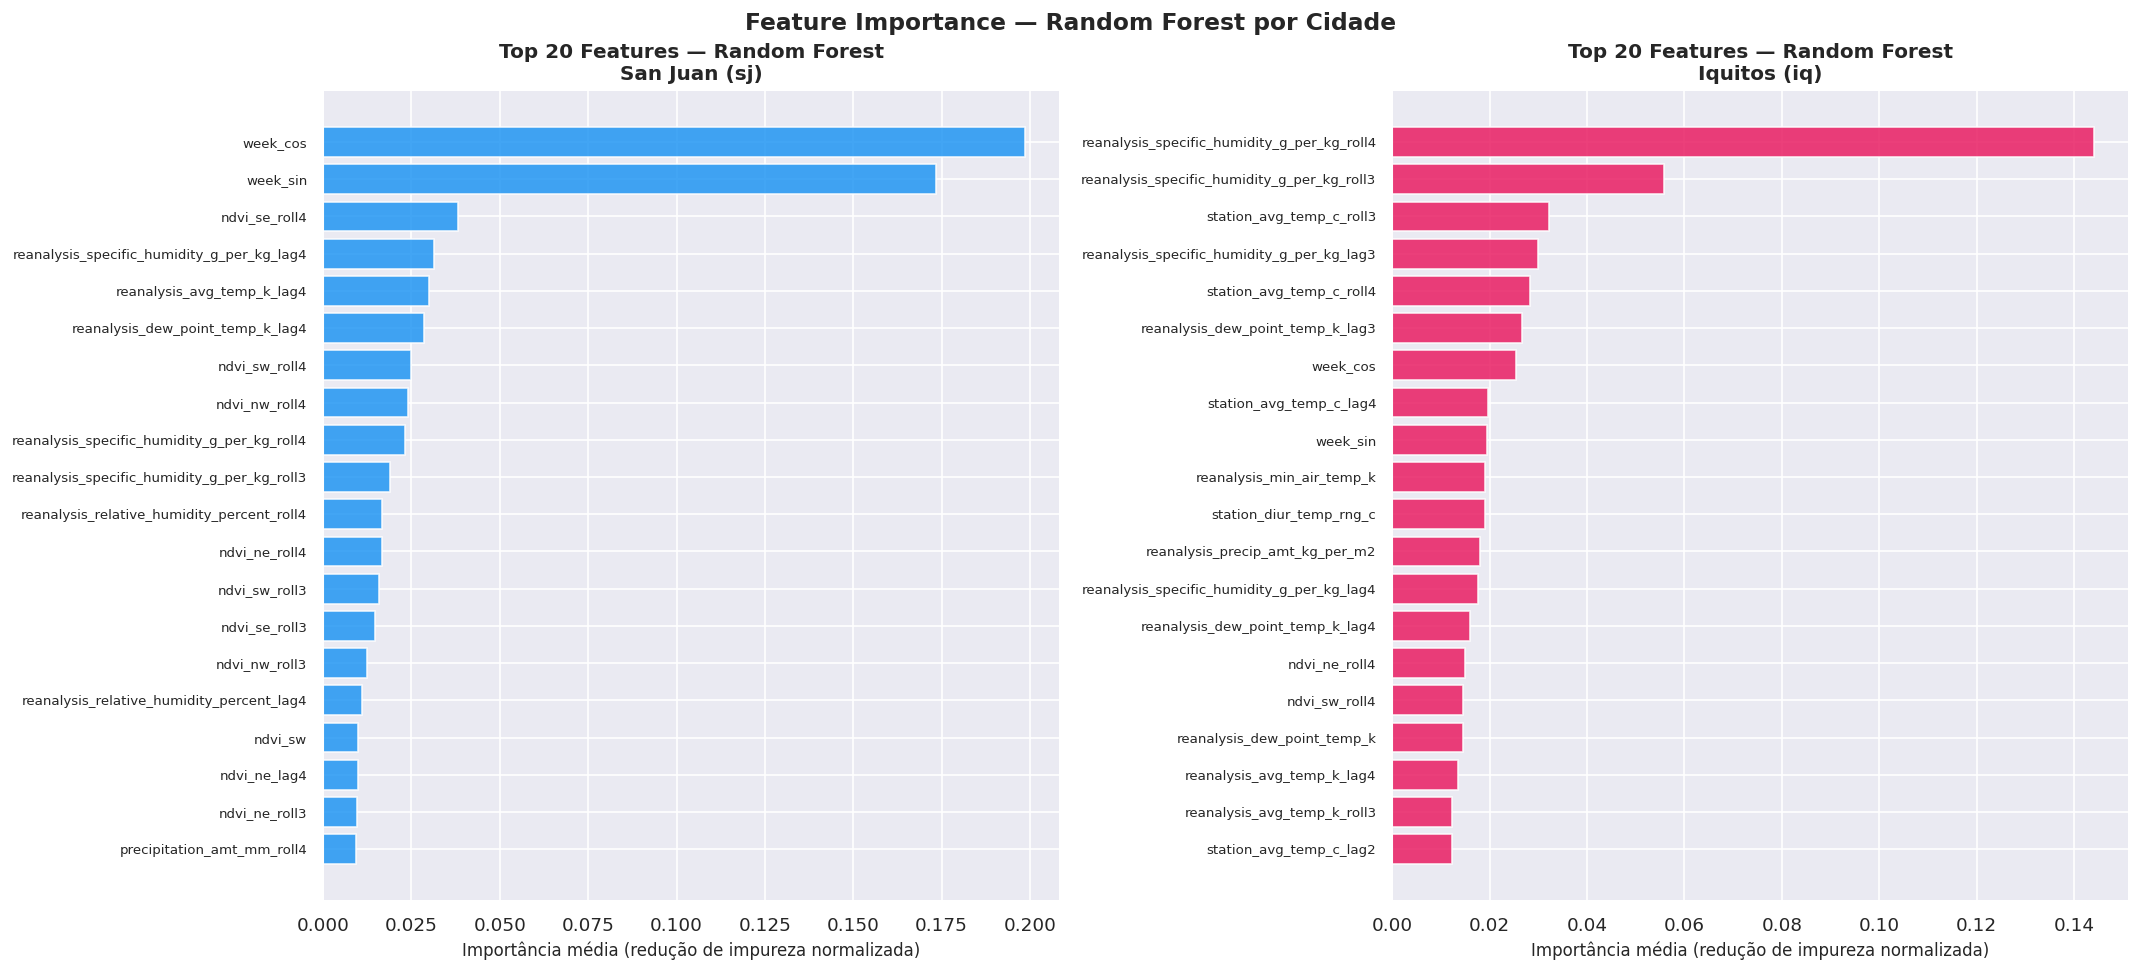

── Top 5 features mais importantes por cidade ──

  SJ:
    1. week_cos                                           0.1985
    2. week_sin                                           0.1735
    3. ndvi_se_roll4                                      0.0382
    4. reanalysis_specific_humidity_g_per_kg_lag4         0.0314
    5. reanalysis_avg_temp_k_lag4                         0.0300

  IQ:
    1. reanalysis_specific_humidity_g_per_kg_roll4        0.1440
    2. reanalysis_specific_humidity_g_per_kg_roll3        0.0559
    3. station_avg_temp_c_roll3                           0.0322
    4. reanalysis_specific_humidity_g_per_kg_lag3         0.0300
    5. station_avg_temp_c_roll4                           0.0282


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, importances, cidade, cor in zip(
        axes,
        [imp_sj, imp_iq],
        ['San Juan (sj)', 'Iquitos (iq)'],
        ['#2196F3', '#E91E63']):

    # Top 20 features por importância
    top_n = 20
    idx_top = np.argsort(importances)[-top_n:]
    top_feats = [feat_cols[i] for i in idx_top]
    top_imps  = importances[idx_top]

    ax.barh(range(top_n), top_imps, color=cor, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats, fontsize=8)
    ax.set_title(f'Top {top_n} Features — Random Forest\n{cidade}', fontweight='bold')
    ax.set_xlabel('Importância média (redução de impureza normalizada)')

plt.tight_layout()
plt.suptitle('Feature Importance — Random Forest por Cidade', y=1.01,
             fontsize=14, fontweight='bold')
plt.show()

# Top 5 por cidade
print("── Top 5 features mais importantes por cidade ──")
for importances, cidade in [(imp_sj, 'SJ'), (imp_iq, 'IQ')]:
    idx_top5 = np.argsort(importances)[-5:][::-1]
    print(f"\n  {cidade}:")
    for rank, i in enumerate(idx_top5, 1):
        print(f"    {rank}. {feat_cols[i]:<50} {importances[i]:.4f}")


 As features de humidade específica e temperatura (especialmente
as variantes com lag de 3-4 semanas e rolling averages) surgem consistentemente
no topo, confirmando a relação epidemiológica com o ciclo do mosquito identificada
no EDA. O encoding cíclico (week_sin, week_cos) também aparece com importância
relevante, confirmando a sazonalidade como predictor forte.


### 6. Comparação dos Modelos Baseline


── Tabela Comparativa dos Modelos Baseline ──
           Modelo  MAE SJ  MAE IQ  MAE Médio  Tempo (s)
Negative Binomial   33.65    6.94      20.29        0.5
    Random Forest   25.90    6.58      16.24        2.8

Referência competitiva: MAE < 25 (agregado)


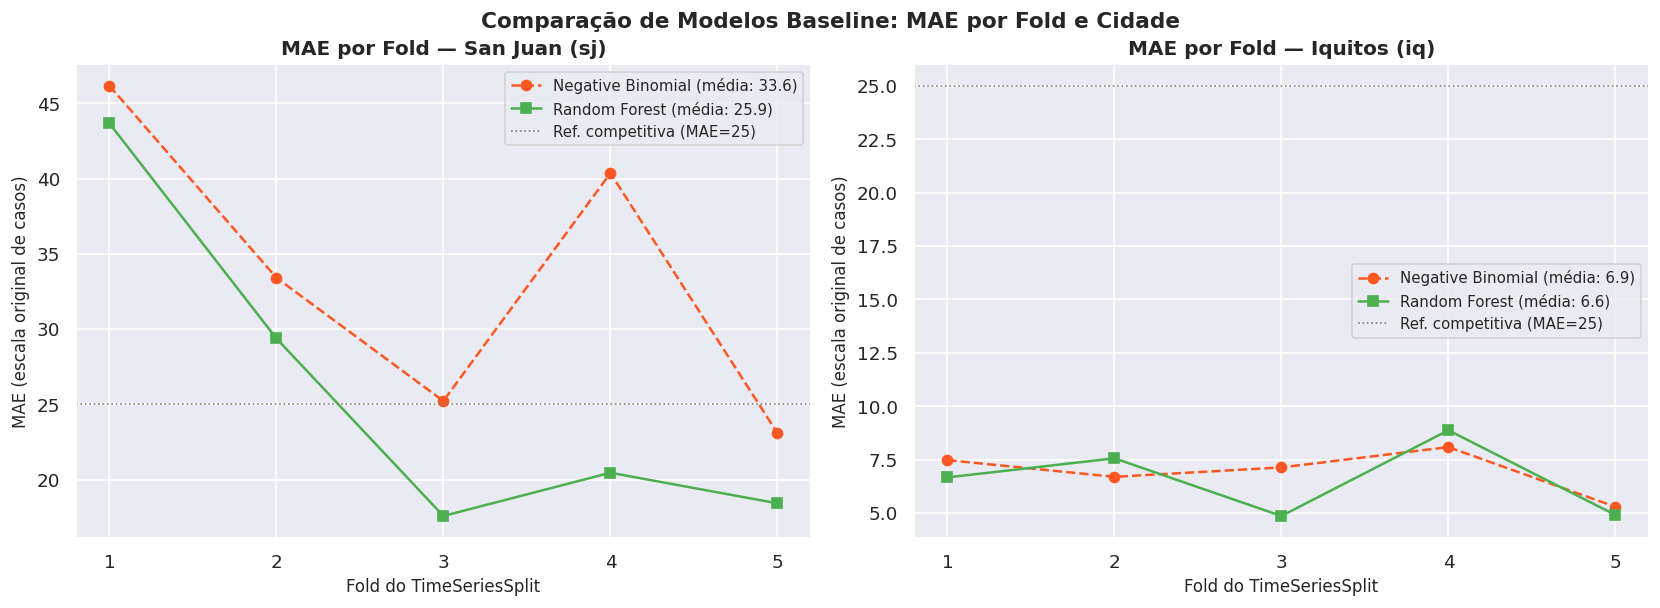

In [7]:
# Tabela comparativa
resultados = {
    'Modelo': ['Negative Binomial', 'Random Forest'],
    'MAE SJ': [round(mae_nb_sj_medio, 2), round(mae_rf_sj_medio, 2)],
    'MAE IQ': [round(mae_nb_iq_medio, 2), round(mae_rf_iq_medio, 2)],
    'MAE Médio': [
        round((mae_nb_sj_medio + mae_nb_iq_medio) / 2, 2),
        round((mae_rf_sj_medio + mae_rf_iq_medio) / 2, 2),
    ],
    'Tempo (s)': [round(t_nb, 1), round(t_rf, 1)],
}
df_resultados = pd.DataFrame(resultados)
print("── Tabela Comparativa dos Modelos Baseline ──")
print(df_resultados.to_string(index=False))
print("\nReferência competitiva: MAE < 25 (agregado)")

# Visualização: MAE por fold por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mae_nb, mae_rf, cidade in zip(
        axes,
        [mae_nb_sj, mae_nb_iq],
        [mae_rf_sj, mae_rf_iq],
        ['San Juan (sj)', 'Iquitos (iq)']):

    folds = range(1, N_FOLDS + 1)
    ax.plot(folds, mae_nb, 'o--', color='#FF5722', linewidth=1.5,
            label=f'Negative Binomial (média: {np.mean(mae_nb):.1f})')
    ax.plot(folds, mae_rf, 's-',  color='#4CAF50', linewidth=1.5,
            label=f'Random Forest (média: {np.mean(mae_rf):.1f})')
    ax.axhline(25, color='grey', linestyle=':', linewidth=1,
               label='Ref. competitiva (MAE=25)')
    ax.set_title(f'MAE por Fold — {cidade}', fontweight='bold')
    ax.set_xlabel('Fold do TimeSeriesSplit')
    ax.set_ylabel('MAE (escala original de casos)')
    ax.legend(fontsize=9)
    ax.set_xticks(folds)

plt.tight_layout()
plt.suptitle('Comparação de Modelos Baseline: MAE por Fold e Cidade',
             y=1.01, fontsize=13, fontweight='bold')
plt.show()
